# DSCI235 Final Project
**Stella Kaulbach** and **Tucker Sussenbach**

// put a github link in???



### Introduction

For this project, we are going to be analyzing a portion of the 2022 Environmental Performance Index (EPI) report which ranks 180 countries on various performance indicators related to environmental health, ecosystem vitality, and climate change. We will focus on the environmental health data, which includes 13 performance indicators specifically focused on quantifying the air quality, sanitation and drinking water, heavy metal (lead) exposure, and waste management of each country over time. 

This data is publicly available in the [EARTHDATA](https://www.earthdata.nasa.gov/) website, which is the portal for the Earth Science Data Systems (ESDS) Program, providing open access to NASA’s archive of Earth science data. Throuhgout this report, we will make use of the information provided in the Technical Appendix, included when you download the data. We have included this pdf in the files on the github repository under the name "2022-epi-technical-appendix.pdf". 

The structure of the data is as follows: there are 13 CSV files, each one focusing on a particular performance indicator for environmental health. A CSV file for a given performance indicator contains a country’s name, ISO code (both the 3 digit abbreviation and the number), and the EPI score for that country for the given performance indicator for years between 1995 and 2022 (inclusive). The way that the data is compiled allows for comparisons of a country over time and countries with each other. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import reduce

### Data Organization and Cleaning

In our initial datasets, each performance indicator includes data for every year from 1995 to 2022 for 220 countries, resulting in a total of around 6,000 intial datapoints. We felt that this was a bit too much to work with, so we decided to streamline our data by only including certain years. By selecting certain years, we can keep our data at a manageable size while still having data that can be used to interpret the changes in each country over time and to analyze the impact that particular events had on these performance indicators. So, we selected 7 different years that span from the late 1990s to the 2020s, each one containing a climate change-related event. 


The years are as follows:

2022 - most recent data availiable

2019 - The UK passes laws that commit to reducing greenhouse gas emissions to net zero by 2050. 

2015 - 196 countries sign up to the Paris Climate Agreement

2008 - The UK Climate Change Act is enshrined in law

2005 - Kyoto Protocol Enters Into Force (The Kyoto Protocol was an international treaty that committed industrialized nations to reduce greenhouse gas emissions.)

1996 - The world’s first carbon storage project gets underway (Carbon storage involves ____________________)

id like to add more to this text ^


**add description here about what we are using to store all our data**

In [132]:
indicators = ["PMD", "HAD", "OZD", "NOE", "SOE", "COE", "VOE", "USD", "UWD", "PBD", "MSW", "REC", "OCP"]
datasets = []

for x in indicators:
    x_init = pd.read_csv("HLT\\"+x+"_ind_na.csv")
    #x_col = x_init[["code","iso","country", x+".ind.2022", x+".ind.2019", x+".ind.2015", x+".ind.2008", x+".ind.2005", x+".ind.1996"]]
    
    
    #x_long = x_col.melt(id_vars=["code", "iso", "country"], var_name="indicator_year", value_name="value") #found this online, id like to make sure i fully understand how it works
    x_long = x_init.melt(id_vars=["code", "iso", "country"], var_name="indicator_year", value_name="value") #found this online, id like to make sure i fully understand how it works
    
    x_long["indicator"] = x
    x_long["year"] = x_long["indicator_year"].str[-4:].astype(int)
    
    x_long = x_long.drop(columns=["indicator_year"])
    
    datasets.append(x_long)
    
all_data = pd.concat(datasets, ignore_index=True)

all_data = all_data.set_index(["code", "iso", "year", "indicator"]).sort_index()

all_data

country      value
code iso year indicator                        
4    AFG 1995 COE        Afghanistan  46.499051
              HAD        Afghanistan   0.000000
              MSW        Afghanistan   1.060000
              NOE        Afghanistan  45.528483
              OCP        Afghanistan        NaN
...                              ...        ...
894  ZMB 2022 REC             Zambia  12.630000
              SOE             Zambia  43.907576
              USD             Zambia  13.924561
              UWD             Zambia  13.248474
              VOE             Zambia  12.812337

[80080 rows x 2 columns]

`iso_dict` is a dictionary that holds the name of each country as the key and then its corresponding numeric code as a value.

In [133]:
iso_dict = all_data["country"].droplevel(("year", "indicator"))
iso_dict = iso_dict.reorder_levels(["code", "iso"]).index
iso_dict = dict(zip(all_data["country"], iso_dict.get_level_values("code")))

In [134]:
unit_dict = {"PMD": "DALY", "HAD": "DALY", "OZD": "DALY", "NOE": "ppm", "SOE": "ppm", "COE": "ppm", "VOE": "ppm", "USD": "DALY", "UWD": "DALY", "PBD": "DALY", "MSW": "proportion", "REC": "tons", "OCP": "proportion"}

In [135]:
years = [1996, 2005, 2008, 2015, 2019, 2022]

To begin, we wanted to determine which performance indicators have the most variability between countries, potentially shedding light on which indicators would be most reflective of the actual overall environmental health of a country. `does this even make sense`

As we cannot do a full analysis on all 13 indicators for all countries, identifying which performance indicators are the most significant can further streamline our analysis.

In [136]:
for p_i in indicators:
    print(f"For {p_i} across all years and all countries, variance is {all_data.xs(p_i, level='indicator').var(numeric_only= True)}")
    


For PMD across all years and all countries, variance is value    498.354534
dtype: float64
For HAD across all years and all countries, variance is value    996.065284
dtype: float64
For OZD across all years and all countries, variance is value    485.096205
dtype: float64
For NOE across all years and all countries, variance is value    780.146925
dtype: float64
For SOE across all years and all countries, variance is value    808.09907
dtype: float64
For COE across all years and all countries, variance is value    684.75984
dtype: float64
For VOE across all years and all countries, variance is value    880.210433
dtype: float64
For USD across all years and all countries, variance is value    956.256235
dtype: float64
For UWD across all years and all countries, variance is value    862.456868
dtype: float64
For PBD across all years and all countries, variance is value    461.026701
dtype: float64
For MSW across all years and all countries, variance is value    1216.981068
dtype: float64


Graphic of US DALY indicators over time


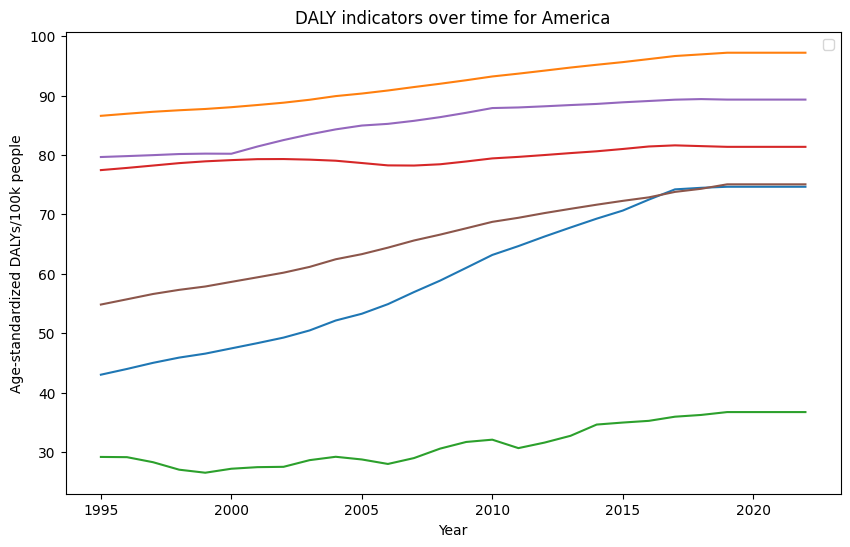

In [138]:
# get the numeric iso code for USA
USA_num = iso_dict.get("United States of America")
USA_data = all_data.loc[USA_num].value


plt.figure(figsize=(10, 6))
gen = (p_i for p_i in indicators if unit_dict.get(p_i) == "DALY")
for p_i in gen:
    plt.plot(USA_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i])


plt.xlabel("Year")
#plt.xticks(years)
plt.ylabel("Age-standardized DALYs/100k people")
plt.title("DALY indicators over time for America") #Disability-Adjusted Life Years) per 100,000 people measure the total health burden, including years of life lost to premature death and years lived with disability, adjusted for population age differences
plt.legend(gen)

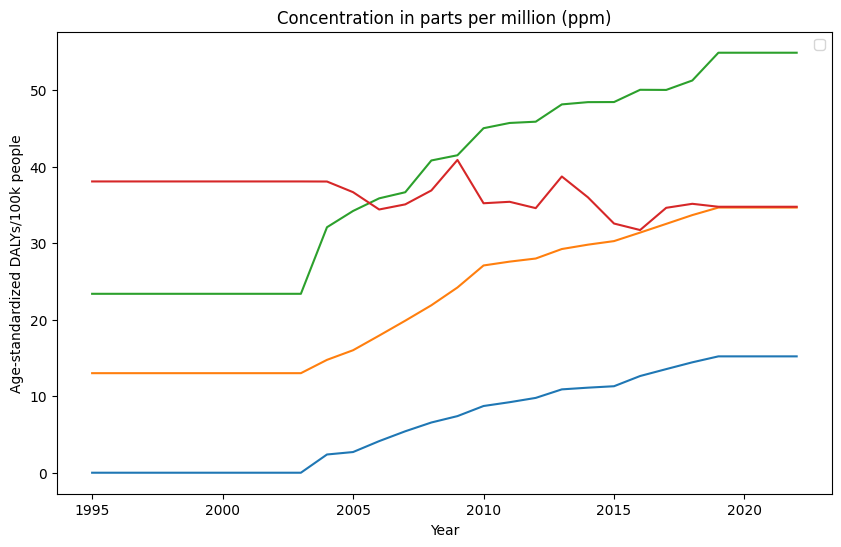

In [ ]:
plt.figure(figsize=(10, 6))
gen = (p_i for p_i in indicators if unit_dict.get(p_i) == "ppm")
for p_i in gen:
    plt.plot(USA_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i])


plt.xlabel("Year")
#plt.xticks(years)
plt.ylabel("Age-standardized DALYs/100k people")
plt.title("Concentration in parts per million (ppm)")
plt.legend(gen) ## need to figure out how to get the right labels in there

### Data Exploration and Analysis

### Conclusion